# Major Project: Seasonal Agriculture Performance Analysis

This notebook analyzes the supplied 4,000-row agricultural dataset according to the project specification: data understanding, cleaning, seasonal comparisons, relationships, statistical analysis, visualization, findings, and recommendations.

## 1. Problem Statement

Agricultural performance varies with seasonal environmental conditions, farming practices, resource availability and market conditions. The goal is to identify meaningful seasonal patterns, trends, relationships and differences in agricultural performance.

## 2. Analytical Questions

1. How does performance vary across seasons?
2. Which season has the strongest yield and economic performance?
3. Which crops perform best in each season?
4. How do environmental conditions differ?
5. How do irrigation and resource usage vary?
6. How does disease/pest risk vary?
7. Which variables are associated with yield/profit?
8. Are seasonal differences statistically significant?
9. Are patterns consistent across states?
10. What evidence-based recommendations can be made?

## 3. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from sklearn.preprocessing import MinMaxScaler
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")


## 4. Load Dataset

In [2]:
DATA_PATH = "../data/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 4,000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


## 5. Dataset Structure

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
display(df.describe(include="all").T)
print("\nColumns:")
for i, col in enumerate(df.columns, 1): print(f"{i:02d}. {col}")


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.000",NaN,NaN,NaN,7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"3,952.000",NaN,NaN,NaN,601.153,288.925,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",NaN,NaN,NaN,26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",NaN,NaN,NaN,63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",NaN,NaN,NaN,7.323,1.121,3.500,6.600,7.300,8.100,11.000



Columns:
01. Farm_ID
02. State
03. District
04. Crop
05. Season
06. Farm_Area_Hectares
07. Rainfall_mm
08. Avg_Temperature_C
09. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


## 6. Data Quality Checks

In [5]:
quality = pd.DataFrame({"Missing_Count":df.isna().sum(), "Missing_Percent":df.isna().mean()*100}).sort_values("Missing_Count", ascending=False)
display(quality[quality.Missing_Count>0])
print("Duplicate rows:", df.duplicated().sum())


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.200
Soil_Moisture_pct,40,1.000
Yield_Tonnes_Ha,32,0.800


Duplicate rows: 0


In [6]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(20))



Farm_ID


Farm_ID
SF10001    1
SF10002    1
SF10003    1
SF10004    1
SF10005    1
SF10006    1
SF10007    1
SF10008    1
SF10009    1
SF10010    1
SF10011    1
SF10012    1
SF10013    1
SF10014    1
SF10015    1
SF10016    1
SF10017    1
SF10018    1
SF10019    1
SF10020    1
Name: count, dtype: int64


State


State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


District


...

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


Season


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


Irrigation_Method


Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

## 7. Cleaning and Preparation

In [7]:
df_raw = df.copy()
df = df.drop_duplicates().copy()
for col in df.select_dtypes(include=["object"]).columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().mean() >= .95: df[col] = converted
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=["object"]).columns:
    if df[col].isna().any() and not df[col].mode().empty: df[col]=df[col].fillna(df[col].mode().iloc[0])
print("Shape after cleaning:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))


Shape after cleaning: (4000, 28)
Remaining missing values: 0


## 8. Core Variables

In [8]:
COL = {
"season":"Season","crop":"Crop","state":"State","district":"District",
"yield":"Yield_Tonnes_Ha","production":"Production_Tonnes","area":"Farm_Area_Hectares",
"rainfall":"Rainfall_mm","temperature":"Avg_Temperature_C","humidity":"Humidity_pct",
"sunlight":"Sunlight_Hours_Day","soil_ph":"Soil_pH","soil_moisture":"Soil_Moisture_pct",
"nitrogen":"Nitrogen_kg_ha","phosphorus":"Phosphorus_kg_ha","potassium":"Potassium_kg_ha",
"irrigation":"Irrigation_Method","fertilizer":"Fertilizer_kg_ha","pesticide":"Pesticide_Litre_ha",
"seed_quality":"Seed_Quality_Score","price":"Market_Price_INR_Tonne","cost":"Total_Cost_INR",
"revenue":"Revenue_INR","profit":"Profit_INR","water":"Water_Used_m3",
"water_efficiency":"Water_Efficiency_t_per_1000m3","risk":"Disease_Pest_Risk_pct"}
display(pd.DataFrame({"Variable":COL.keys(),"Column":COL.values()}))


,Variable,Column
0,season,Season
1,crop,Crop
2,state,State
3,district,District
4,yield,Yield_Tonnes_Ha
5,production,Production_Tonnes
6,area,Farm_Area_Hectares
7,rainfall,Rainfall_mm
8,temperature,Avg_Temperature_C
9,humidity,Humidity_pct


## 9. Seasonal Record Distribution

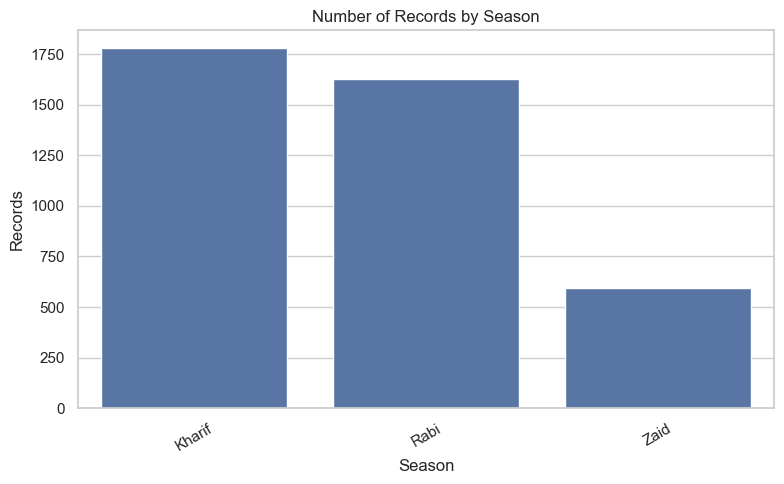

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x=COL["season"], order=df[COL["season"]].value_counts().index)
plt.title("Number of Records by Season"); plt.xlabel("Season"); plt.ylabel("Records"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 10. Seasonal Performance Summary

In [10]:
metrics=[COL[k] for k in ["yield","production","revenue","cost","profit","water","water_efficiency","risk"]]
season_summary=df.groupby(COL["season"])[metrics].agg(["count","mean","median","std"]).round(3)
display(season_summary)


Yield_Tonnes_Ha                     Production_Tonnes                \
                 count  mean median    std             count   mean median   
Season                                                                       
Kharif            1779 5.629  1.940 14.393              1779 46.311 13.240   
Rabi              1627 5.039  1.670 12.752              1627 41.487 11.080   
Zaid               594 4.641  1.460 11.273               594 38.886  9.970   

               Revenue_INR                                     Total_Cost_INR  \
           std       count        mean      median         std          count   
Season                                                                          
Kharif 135.705        1779 710,719.056 520,196.000 708,710.370           1779   
Rabi   121.905        1627 601,526.049 438,156.000 584,545.521           1627   
Zaid   112.001         594 519,171.904 373,700.500 509,524.546            594   

                                           Profit_INR                          \
              mean      median         std      count        mean      median   
Season                                                                          
Kharif 531,804.408 524,840.000 298,487.687       1779 178,914.648  38,808.000   
Rabi   513,836.578 506,733.000 288,386.892       1627  87,689.470  -3,187.000   
Zaid   543,976.729 534,833.000 297,576.859        594 -24,804.825 -62,144.000   

                   Water_Used_m3                                \
               std         count      mean    median       std   
Season                                                           
Kharif 611,549.784          1779 6,102.201 4,469.000 5,670.583   
Rabi   489,901.254          1627 5,846.987 4,292.000 5,397.648   
Zaid   436,356.747           594 6,419.894 4,805.000 5,734.620   

       Water_Efficiency_t_per_1000m3                    Disease_Pest_Risk_pct  \
                               count  mean median   std                 count   
Season                                                                          
Kharif                          1779 5.892  3.277 9.833                  1779   
Rabi                            1627 5.186  2.740 8.258                  1627   
Zaid                             594 4.413  2.302 6.930                   594   

                             
         mean median    std  
Season                       
Kharif 54.468 54.500 10.088  
Rabi   40.482 40.600 10.104  
Zaid   38.217 37.900  9.874

## 11. Average Yield by Season

,Average
Season,
Kharif,5.629
Rabi,5.039
Zaid,4.641


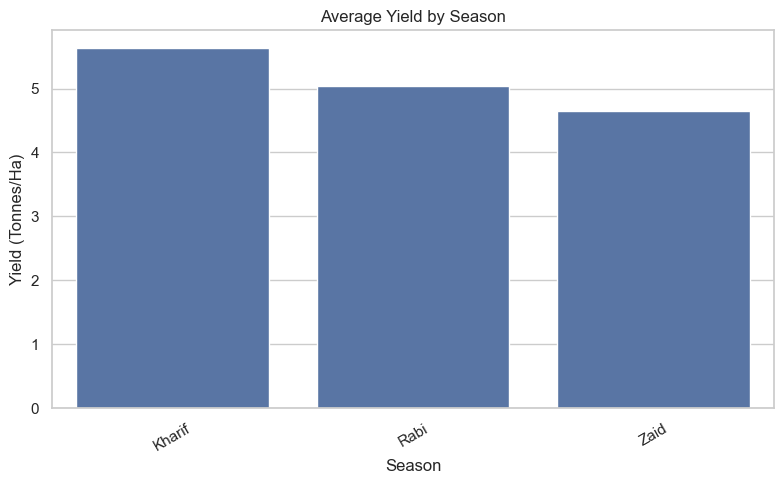

In [11]:
s=df.groupby(COL["season"])[COL["yield"]].mean().sort_values(ascending=False)
display(s.to_frame("Average"))
plt.figure(figsize=(8,5)); sns.barplot(data=df,x=COL["season"],y=COL["yield"],estimator="mean",errorbar=None); plt.title("Average Yield by Season"); plt.ylabel("Yield (Tonnes/Ha)"); plt.xlabel("Season"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 12. Average Profit by Season

,Average
Season,
Kharif,"178,914.648"
Rabi,"87,689.470"
Zaid,"-24,804.825"


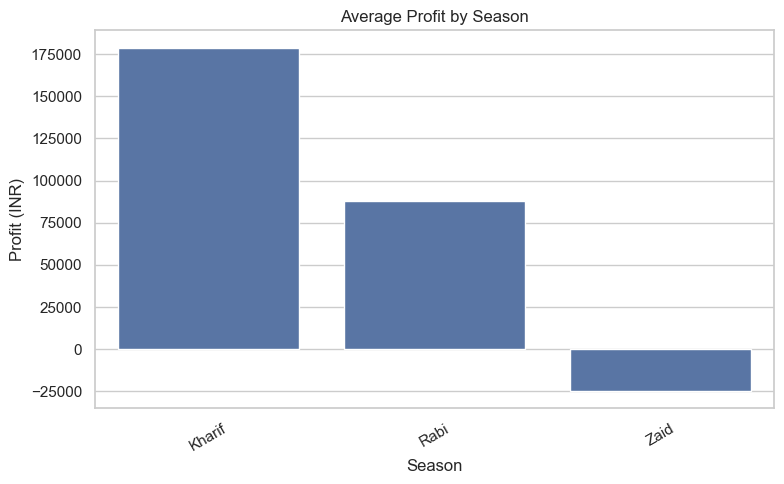

In [12]:
s=df.groupby(COL["season"])[COL["profit"]].mean().sort_values(ascending=False)
display(s.to_frame("Average"))
plt.figure(figsize=(8,5)); sns.barplot(data=df,x=COL["season"],y=COL["profit"],estimator="mean",errorbar=None); plt.title("Average Profit by Season"); plt.ylabel("Profit (INR)"); plt.xlabel("Season"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 13. Water Efficiency by Season

,Average
Season,
Kharif,5.892
Rabi,5.186
Zaid,4.413


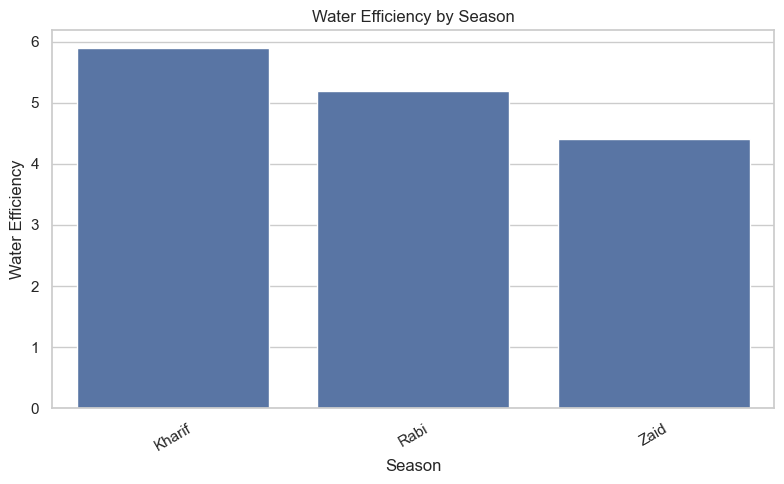

In [13]:
s=df.groupby(COL["season"])[COL["water_efficiency"]].mean().sort_values(ascending=False)
display(s.to_frame("Average"))
plt.figure(figsize=(8,5)); sns.barplot(data=df,x=COL["season"],y=COL["water_efficiency"],estimator="mean",errorbar=None); plt.title("Water Efficiency by Season"); plt.ylabel("Water Efficiency"); plt.xlabel("Season"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 14. Revenue and Cost by Season

,Revenue_INR,Total_Cost_INR
Season,,
Kharif,"710,719.056","531,804.408"
Rabi,"601,526.049","513,836.578"
Zaid,"519,171.904","543,976.729"


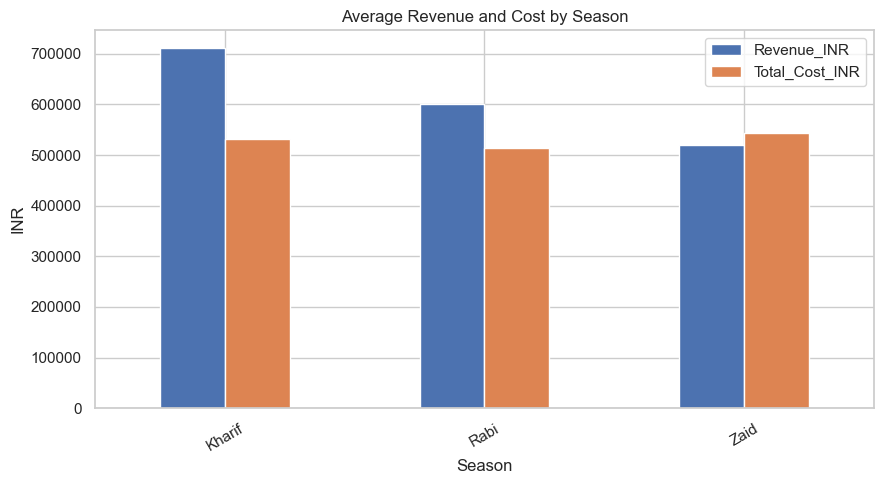

In [14]:
econ=df.groupby(COL["season"])[[COL["revenue"],COL["cost"]]].mean()
display(econ)
econ.plot(kind="bar",figsize=(9,5)); plt.title("Average Revenue and Cost by Season"); plt.xlabel("Season"); plt.ylabel("INR"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 15. Environmental Conditions by Season

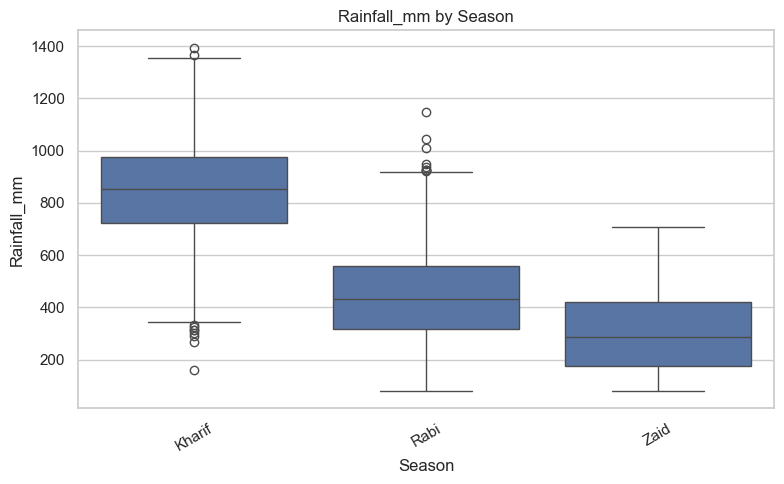

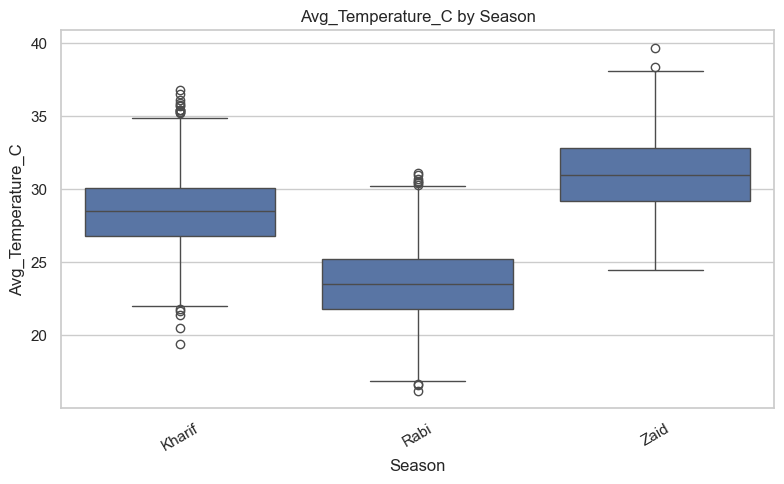

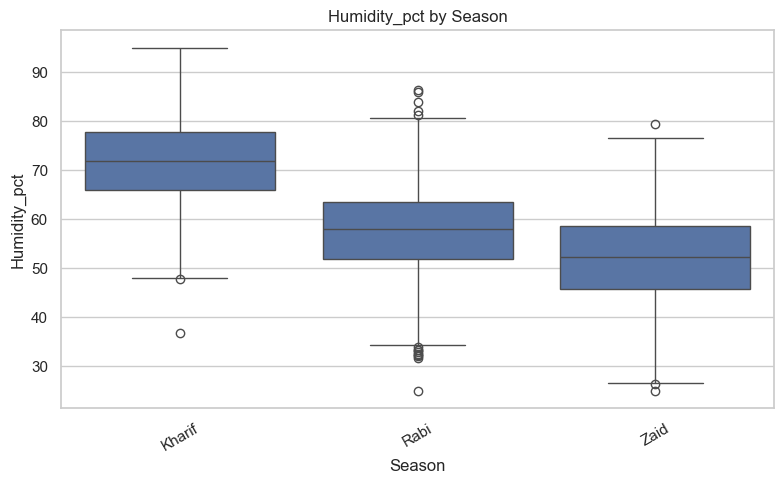

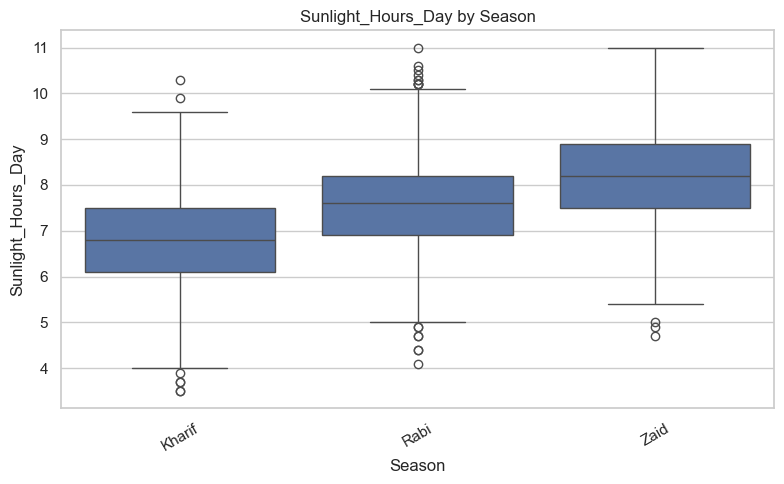

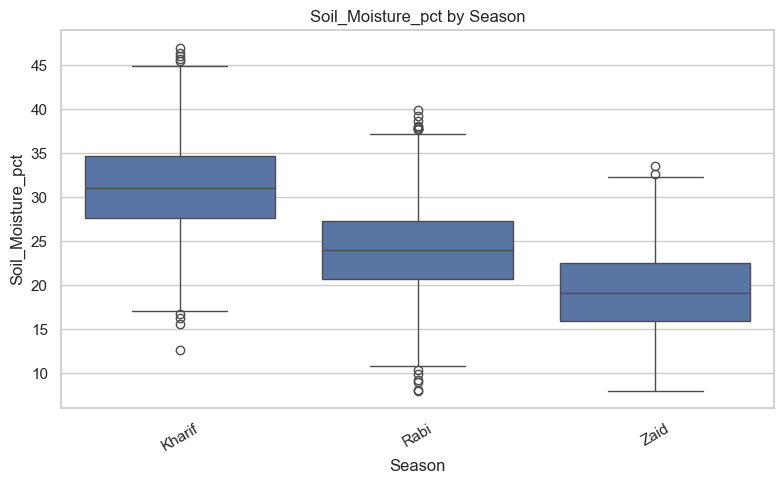

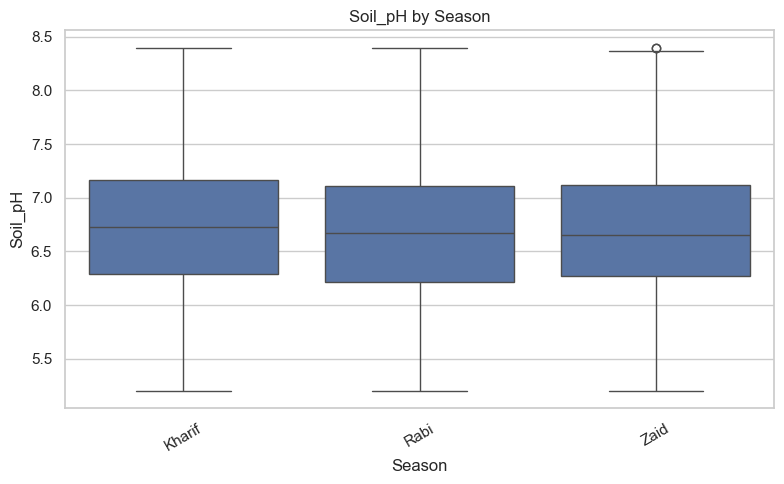

In [15]:
for k in ["rainfall","temperature","humidity","sunlight","soil_moisture","soil_ph"]:
    col=COL[k]
    plt.figure(figsize=(8,5)); sns.boxplot(data=df,x=COL["season"],y=col); plt.title(f"{col} by Season"); plt.xlabel("Season"); plt.ylabel(col); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 16. Crop × Season Yield Analysis

,Crop,Season,Yield_Tonnes_Ha
18,Sugarcane,Kharif,53.459
19,Sugarcane,Rabi,43.286
20,Sugarcane,Zaid,38.424
9,Maize,Kharif,2.966
15,Rice,Kharif,2.698
10,Maize,Rabi,2.604
16,Rice,Rabi,2.323
11,Maize,Zaid,2.291
21,Wheat,Kharif,2.254
22,Wheat,Rabi,2.057


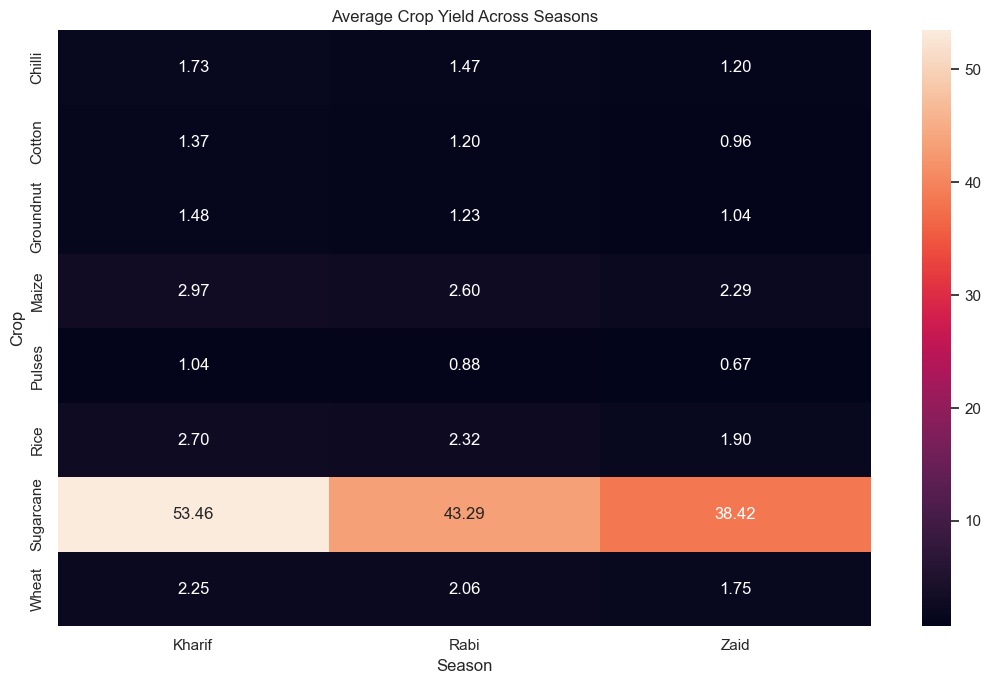

In [16]:
crop_season=df.groupby([COL["crop"],COL["season"]])[COL["yield"]].mean().reset_index()
display(crop_season.sort_values(COL["yield"],ascending=False).head(20))
pivot=crop_season.pivot(index=COL["crop"],columns=COL["season"],values=COL["yield"])
plt.figure(figsize=(11,7)); sns.heatmap(pivot,annot=True,fmt=".2f"); plt.title("Average Crop Yield Across Seasons"); plt.tight_layout(); plt.show()


## 17. Irrigation × Season

,Season,Irrigation_Method,Yield_Tonnes_Ha
0,Kharif,Drip,7.256
1,Kharif,Flood,4.978
2,Kharif,Rainfed,5.704
3,Kharif,Sprinkler,4.662
4,Rabi,Drip,6.112
5,Rabi,Flood,5.061
6,Rabi,Rainfed,3.929
7,Rabi,Sprinkler,5.307
8,Zaid,Drip,5.848
9,Zaid,Flood,3.984


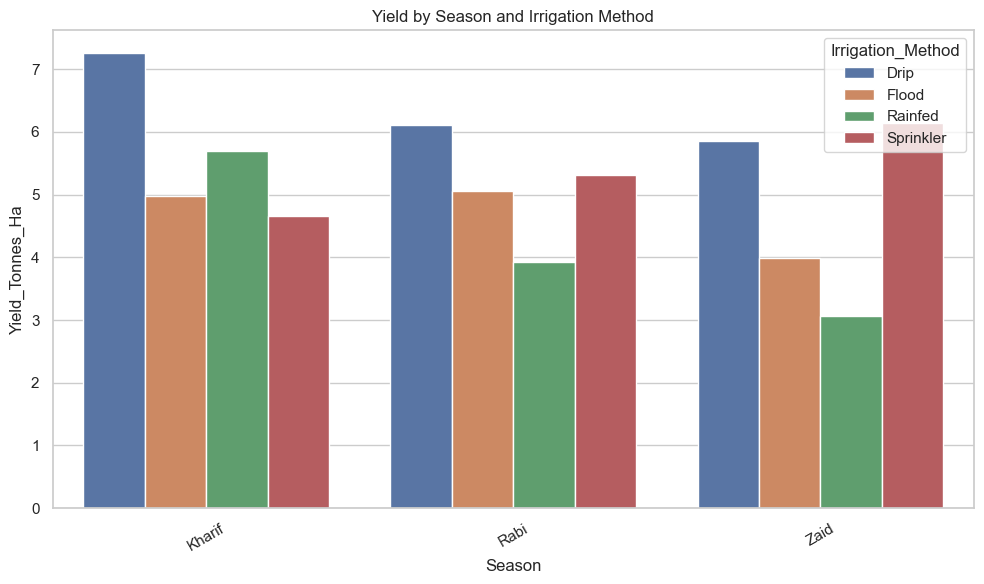

In [17]:
ir=df.groupby([COL["season"],COL["irrigation"]])[COL["yield"]].mean().reset_index()
display(ir)
plt.figure(figsize=(10,6)); sns.barplot(data=ir,x=COL["season"],y=COL["yield"],hue=COL["irrigation"],errorbar=None); plt.title("Yield by Season and Irrigation Method"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 18. Disease/Pest Risk

,mean,median,std
Season,,,
Kharif,54.468,54.500,10.088
Rabi,40.482,40.600,10.104
Zaid,38.217,37.900,9.874


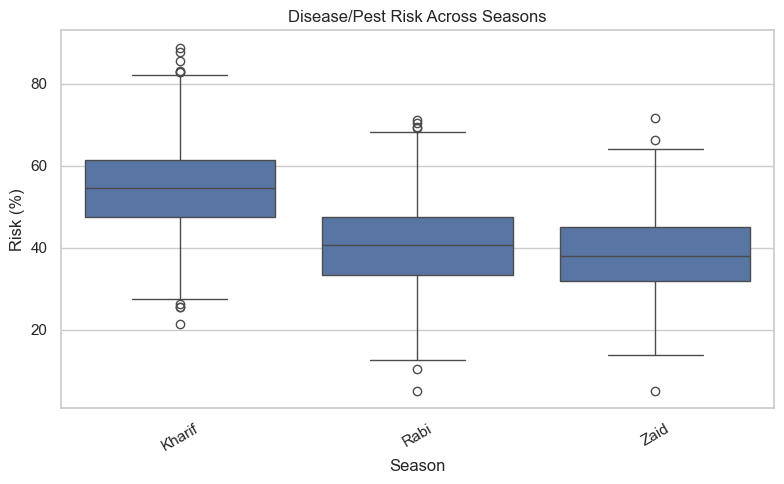

In [18]:
risk=df.groupby(COL["season"])[COL["risk"]].agg(["mean","median","std"]).round(3); display(risk)
plt.figure(figsize=(8,5)); sns.boxplot(data=df,x=COL["season"],y=COL["risk"]); plt.title("Disease/Pest Risk Across Seasons"); plt.ylabel("Risk (%)"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 19. Economic Efficiency Features

In [19]:
df["Profit_per_Hectare"]=df[COL["profit"]]/df[COL["area"]].replace(0,np.nan)
df["Revenue_per_Hectare"]=df[COL["revenue"]]/df[COL["area"]].replace(0,np.nan)
df["Cost_per_Hectare"]=df[COL["cost"]]/df[COL["area"]].replace(0,np.nan)
display(df.groupby(COL["season"])[["Profit_per_Hectare","Revenue_per_Hectare","Cost_per_Hectare"]].mean().round(2))


,Profit_per_Hectare,Revenue_per_Hectare,Cost_per_Hectare
Season,,,
Kharif,"21,881.810","88,782.790","66,900.980"
Rabi,"10,361.680","76,656.920","66,295.240"
Zaid,"-2,636.520","64,301.420","66,937.940"


## 20. Internal Consistency Checks

In [20]:
df["Calculated_Production"]=df[COL["yield"]]*df[COL["area"]]
df["Production_Error"]=df[COL["production"]]-df["Calculated_Production"]
df["Calculated_Profit"]=df[COL["revenue"]]-df[COL["cost"]]
df["Profit_Error"]=df[COL["profit"]]-df["Calculated_Profit"]
print("Production error:"); display(df["Production_Error"].describe())
print("Profit error:"); display(df["Profit_Error"].describe())


Production error:


count   4,000.000
mean        0.195
std         9.094
min       -17.263
25%        -0.002
50%         0.000
75%         0.002
max       508.000
Name: Production_Error, dtype: float64

Profit error:


count   4,000.000
mean        0.000
std         0.000
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.000
Name: Profit_Error, dtype: float64

## 21. Correlation Analysis

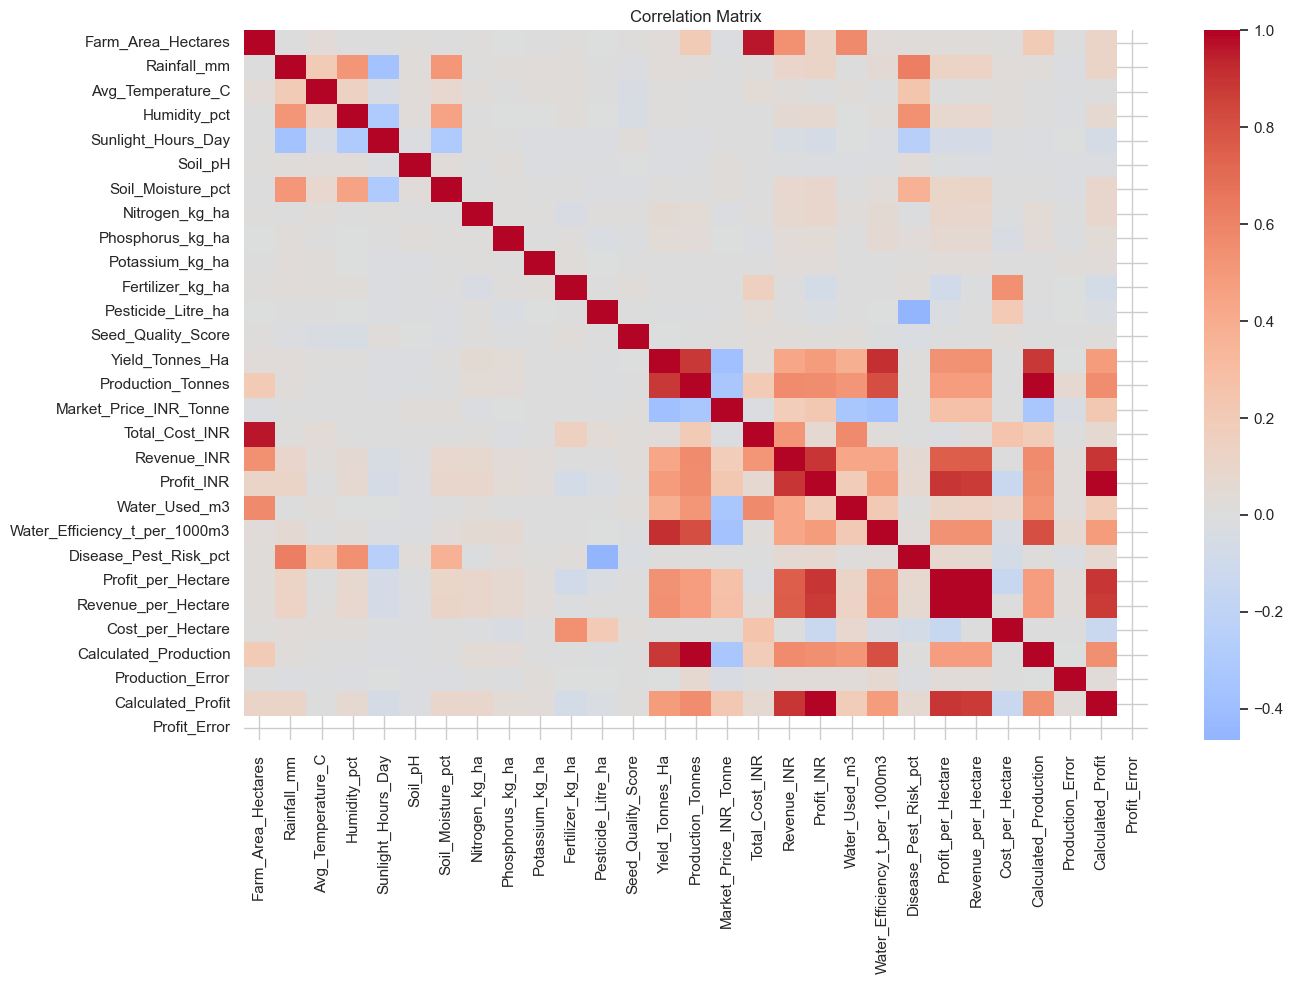

In [21]:
corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(14,10)); sns.heatmap(corr,center=0,cmap="coolwarm"); plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()


In [22]:
yc=corr[COL["yield"]].drop(COL["yield"]).sort_values(key=lambda x:x.abs(),ascending=False)
display(yc.to_frame("Correlation_with_Yield"))


,Correlation_with_Yield
Water_Efficiency_t_per_1000m3,0.913
Calculated_Production,0.885
Production_Tonnes,0.883
Revenue_per_Hectare,0.542
Profit_per_Hectare,0.535
Profit_INR,0.488
Calculated_Profit,0.488
Revenue_INR,0.432
Water_Used_m3,0.386
Market_Price_INR_Tonne,-0.383


## 22. Statistical Testing of Seasonal Yield

In [23]:
groups=[g[COL["yield"]].dropna().values for _,g in df.groupby(COL["season"])]
labels=list(df.groupby(COL["season"]).groups.keys())
anova=f_oneway(*groups); kw=kruskal(*groups)
print("Seasons:",labels)
print(f"ANOVA F={anova.statistic:.4f}, p={anova.pvalue:.6g}")
print(f"Kruskal-Wallis H={kw.statistic:.4f}, p={kw.pvalue:.6g}")


Seasons: ['Kharif', 'Rabi', 'Zaid']
ANOVA F=1.5439, p=0.213678
Kruskal-Wallis H=68.7131, p=1.19991e-15


## 23. Outlier Analysis

In [24]:
def outlier_report(data,col):
    q1=data[col].quantile(.25); q3=data[col].quantile(.75); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr; mask=(data[col]<lo)|(data[col]>hi)
    return [col,q1,q3,lo,hi,int(mask.sum()),mask.mean()*100]
outs=[COL[k] for k in ["yield","profit","rainfall","water","risk"]]
display(pd.DataFrame([outlier_report(df,c) for c in outs],columns=["Column","Q1","Q3","Lower","Upper","Count","Percent"]))


,Column,Q1,Q3,Lower,Upper,Count,Percent
0,Yield_Tonnes_Ha,1.050,2.830,-1.620,5.500,302,7.550
1,Profit_INR,"-148,731.750","216,187.750","-696,111.000","763,567.000",404,10.100
2,Rainfall_mm,371.575,831.975,-319.025,"1,522.575",0,0.000
3,Water_Used_m3,"2,268.750","7,829.750","-6,072.750","16,171.250",276,6.900
4,Disease_Pest_Risk_pct,37.300,54.900,10.900,81.300,10,0.250


## 24. State × Season Analysis

,State,Season,Yield_Tonnes_Ha
0,Andhra Pradesh,Kharif,5.677
1,Andhra Pradesh,Rabi,3.471
2,Andhra Pradesh,Zaid,4.448
3,Gujarat,Kharif,6.338
4,Gujarat,Rabi,5.442
5,Gujarat,Zaid,4.067
6,Karnataka,Kharif,6.455
7,Karnataka,Rabi,4.568
8,Karnataka,Zaid,6.623
9,Madhya Pradesh,Kharif,5.985


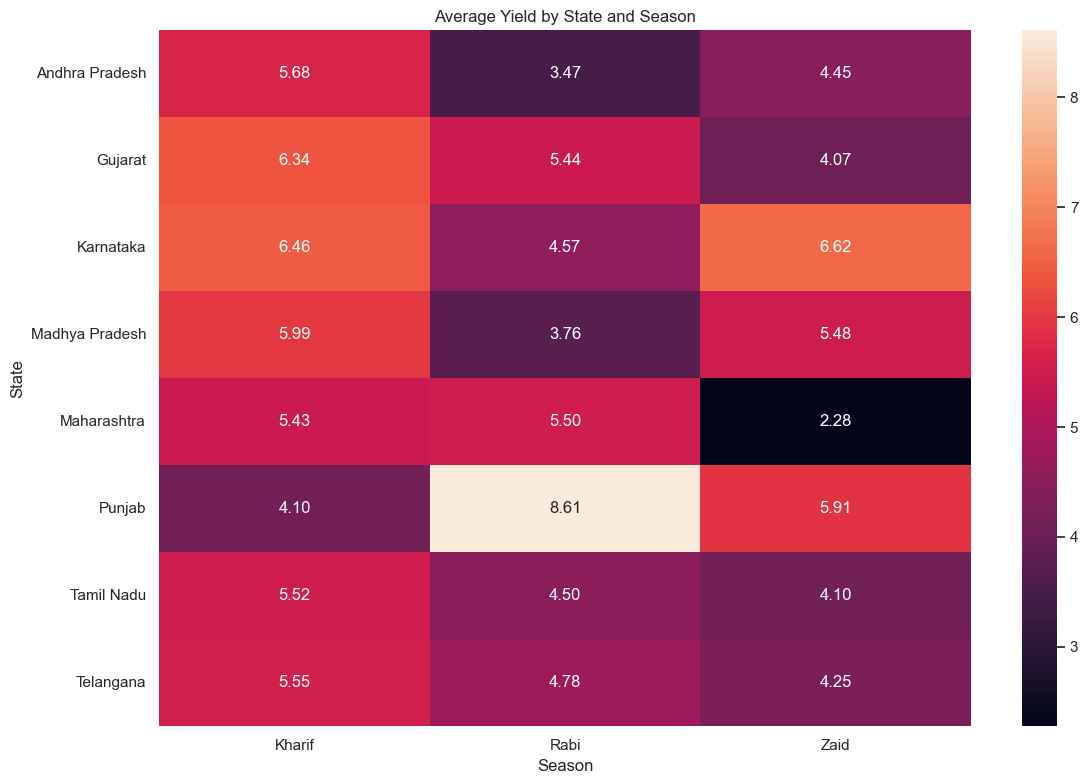

In [25]:
state_season=df.groupby([COL["state"],COL["season"]])[COL["yield"]].mean().reset_index()
display(state_season.head(30))
p=state_season.pivot(index=COL["state"],columns=COL["season"],values=COL["yield"])
plt.figure(figsize=(12,8)); sns.heatmap(p,annot=True,fmt=".2f"); plt.title("Average Yield by State and Season"); plt.tight_layout(); plt.show()


## 25. Optional Agricultural Performance Index

In [26]:
features=[COL["yield"],COL["profit"],COL["water_efficiency"],COL["risk"]]
scaled=pd.DataFrame(MinMaxScaler().fit_transform(df[features]),columns=features,index=df.index)
# Higher yield/profit/water efficiency are positive; lower risk is positive.
df["Agricultural_Performance_Index"]=(scaled[COL["yield"]]+scaled[COL["profit"]]+scaled[COL["water_efficiency"]]+(1-scaled[COL["risk"]]))/4
display(df.groupby(COL["season"])["Agricultural_Performance_Index"].mean().sort_values(ascending=False).to_frame())


,Agricultural_Performance_Index
Season,
Rabi,0.223
Zaid,0.222
Kharif,0.190


## 26. Automated Evidence Summary

In [27]:
s=df.groupby(COL["season"])
y=s[COL["yield"]].mean().sort_values(ascending=False); p=s[COL["profit"]].mean().sort_values(ascending=False); w=s[COL["water_efficiency"]].mean().sort_values(ascending=False); r=s[COL["risk"]].mean().sort_values()
print(f"Highest average yield: {y.index[0]} ({y.iloc[0]:.3f} Tonnes/Ha)")
print(f"Lowest average yield: {y.index[-1]} ({y.iloc[-1]:.3f} Tonnes/Ha)")
print(f"Highest average profit: {p.index[0]} ({p.iloc[0]:,.2f} INR)")
print(f"Highest water efficiency: {w.index[0]} ({w.iloc[0]:.3f})")
print(f"Lowest average disease/pest risk: {r.index[0]} ({r.iloc[0]:.3f}%)")


Highest average yield: Kharif (5.629 Tonnes/Ha)
Lowest average yield: Zaid (4.641 Tonnes/Ha)
Highest average profit: Kharif (178,914.65 INR)
Highest water efficiency: Kharif (5.892)
Lowest average disease/pest risk: Zaid (38.217%)


## 27. Key Findings

After running the notebook, replace the placeholders with the exact values produced above.

- Seasonal yield: [highest/lowest season and values].
- Economic performance: [highest/lowest profit].
- Environmental conditions: [major seasonal differences].
- Crop performance: [best crop-season combinations].
- Resource efficiency: [water usage/efficiency differences].
- Risk: [disease/pest differences].
- Regional consistency: [state-level seasonal patterns].
- Statistical evidence: [ANOVA and Kruskal-Wallis p-values].
- Outliers: [important unusual observations].

## 28. Evidence-Based Recommendations

1. Prioritize crop-season combinations that show consistently strong performance.
2. Investigate low water-efficiency seasons/regions and evaluate efficient irrigation practices.
3. Strengthen disease/pest monitoring where the dataset indicates elevated risk.
4. Use state/district differences for targeted planning.
5. Compare profit per hectare when farm sizes differ.
6. Validate unusual observations before operational decisions.

Recommendations should be edited to match the actual findings.

## 29. Conclusion

Summarize the seasonal differences, important environmental/resource/economic associations, statistical evidence, and practical planning insights. Avoid causal claims when the analysis only demonstrates correlation.

## 30. Save Cleaned Dataset

In [28]:
OUTPUT_CLEAN="../data/seasonal_agriculture_cleaned.csv"
df.to_csv(OUTPUT_CLEAN,index=False)
print("Saved:",OUTPUT_CLEAN)


Saved: ../data/seasonal_agriculture_cleaned.csv
